In [38]:
# Installing Pillow Libraries
!pip install scikit-learn matplotlib Pillow


[notice] A new release of pip is available: 23.1.2 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import numpy as np
import os
from random import randrange
from matplotlib import pyplot as plt
from PIL import Image

from random import randrange
from matplotlib import pyplot as plt
import pandas as pd
import sklearn.decomposition as sk
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score


In [40]:
cfw_dict = {
    'Amitabhbachan': 0,
    'AamirKhan': 1,
    'DwayneJohnson': 2,
    'AishwaryaRai': 3,
    'BarackObama': 4,
    'NarendraModi': 5,
    'ManmohanSingh': 6,
    'VladimirPutin': 7
}

opt = {
    'image_size': 32,
    'is_grayscale': False,
    'val_split': 0.75
}

In [41]:
def load_image(path):
    im = Image.open(path).convert('L' if opt['is_grayscale'] else 'RGB')
    im = im.resize((opt['image_size'],opt['image_size']))
    im = np.array(im)
    im = im/256
    return im

def display_images(imgs,classes,row=1,col=2,w=32,h=32):
    fig=plt.figure(figsize=(8, 8))
    for i in range(1, col*row +1):
        img = imgs[i-1]
        fig.add_subplot(row, col, i)
        
        if opt['is_grayscale']:
            plt.imshow(img , cmap='gray') 
        else:
            plt.imshow(img)
        
        plt.title("Class:{}".format(classes[i-1]))
        plt.axis('off')
    plt.show()

def load_data(dir_path):
    image_list = []
    y_list = []
    label_dict = cfw_dict
    for filename in sorted(os.listdir(dir_path)):
        if filename.endswith(".png"):
            im = load_image(os.path.join(dir_path,filename))
            y = filename.split('_')[0]
            y = label_dict[y] 
            image_list.append(im)
            y_list.append(y)
        else:
            continue
    image_list = np.array(image_list)
    y_list = np.array(y_list)
    print("Dataset shape:",image_list.shape)
    print("Label shape:",y_list.shape)

    return image_list,y_list

In [42]:
dirpath = 'IIIT-CFW/'
X,y = load_data(dirpath)

Dataset shape: (672, 32, 32, 3)
Label shape: (672,)


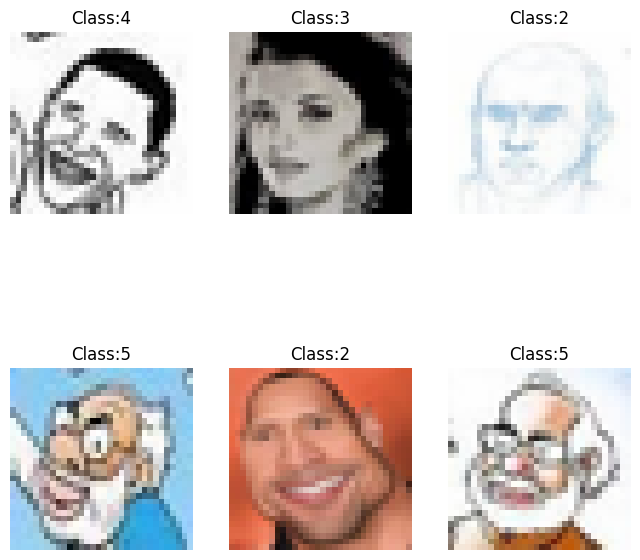

In [43]:
N,H,W = X.shape[0:3]
C = 1 if opt['is_grayscale'] else X.shape[3]

ind = np.random.randint(0,y.shape[0],6)
display_images(X[ind,...],y[ind], row=2,col=3)

#  Problem 1

## 1.1 PCA

In [44]:
# References used 
# https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/decomposition/_pca.py
# https://alex.smola.org/teaching/cmu2013-10-701/slides/14_PrincipalComp.pdf

In [45]:
# Fit function was inspired from ChatGPT

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.eigenvalues = None

    def preprocess(self, data):
        mean = np.mean(data, axis = 0)
        sd = np.std(data, axis = 0)
        data -= mean
        data = data / sd
        return data
        
    def fit(self, input):
        cov_matrix = np.cov(input, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # eigenvalue of covariance matrix
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, sorted_indices]
        self.components = eigenvectors[:, :self.n_components]
        eigenvalues=sorted(eigenvalues)
        self.eigenvalues = eigenvalues[len(eigenvalues)-self.n_components:]
        return

    def transform(self, input):
        reduced_data = np.dot(input, self.components)
        return reduced_data

    def evaluate(self, input):
        cum_exp_var_ratio = []
        sum_eig = np.sum(self.eigenvalues)
        sum = 0
        
        for itr in range(self.n_components-1, -1, -1):
            sum += self.eigenvalues[itr]
            if (sum_eig == 0):
                cum_exp_var_ratio.append(0)
            else:
                cum_exp_var_ratio.append(sum/sum_eig)

        cum_exp_var_ratio = np.array(cum_exp_var_ratio)
        num_pc = list(range(1, self.n_components + 1))
        
        return num_pc, cum_exp_var_ratio
        

## IIIT-CFW dataset

C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\BPATR\OneDrive\Desktop\smai_assgn\assgn\Lib\site-packages\matplotlib\collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


[]

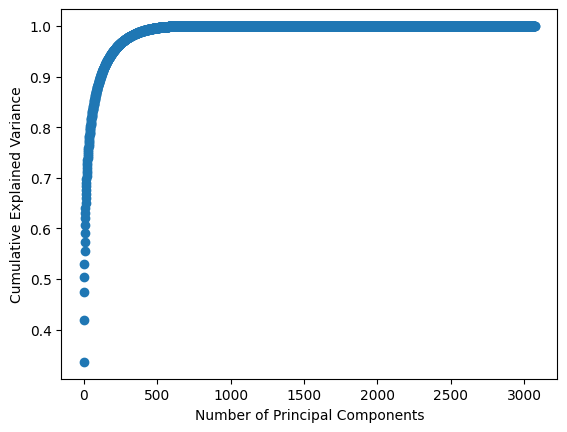

In [46]:
input_cfw = X.reshape(X.shape[0], X.shape[1]*X.shape[2]*X.shape[3])

pca = PCA(input_cfw.shape[1])
flatten = pca.preprocess(input_cfw)
pca.fit(input_cfw)
red_data = pca.transform(input_cfw)

num_pc, cum_exp_var_r = pca.evaluate(input_cfw)

plt.scatter(num_pc, cum_exp_var_r)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.plot()

## Assignment 1 Pictionary Dataset

For VIT Dataset: Accuracy=0.20333333333333334, Precision=0.6211044973544974, Recall=0.20333333333333334, F1 Score=0.19182869567080094


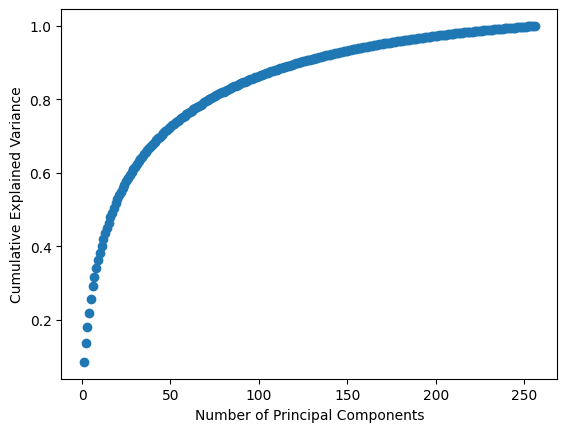

In [47]:
# For VIT Encoding

# Loading dataset
dataset = np.load('./data.npy', allow_pickle=True)

# #print(dataset.shape)  # Printing the shape of the dataset
# #print(dataset)        # Printing the entire dataset

Resnet_input = []
VIT_input = []
label = []
for i in dataset:
    label.append(i[3])
    for j in i[1]:
       Resnet_input.append(j)
    for j in i[2]:
        VIT_input.append(j)

pca = PCA(256)
VIT_input = pca.preprocess(VIT_input)
pca.fit(VIT_input)
red_data = pca.transform(VIT_input)
num_pc, cum_exp_var_ratio = pca.evaluate(VIT_input)

plt.scatter(num_pc, cum_exp_var_ratio)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.plot()

knn = KNeighborsClassifier()
X_train, X_test, y_train, y_test = train_test_split(red_data, label, test_size=0.2, random_state = None)

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1, average='weighted')
recall = recall_score(y_test, y_pred, zero_division=1, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("For VIT Dataset: Accuracy={}, Precision={}, Recall={}, F1 Score={}".format(accuracy, precision, recall, f1))


Previous Values: <br>
Best Model -> k: 13, Embedding: VIT, Distance Metric: manhattan <br>
Metrices -> Accuracy = 0.26867550260197315, Precision = 0.2966666666666667, Recall = 0.5822279942279942, F1 Score = 0.2966666666666667
<br>
We can observe that even with half the components we are able to achieve similar metric values. 

For VIT Dataset: Accuracy=0.01, Precision=0.45392156862745103, Recall=0.01, F1 Score=0.011
For VIT Dataset: Accuracy=0.023333333333333334, Precision=0.5291666666666667, Recall=0.023333333333333334, F1 Score=0.023015873015873017
For VIT Dataset: Accuracy=0.03333333333333333, Precision=0.4256111111111111, Recall=0.03333333333333333, F1 Score=0.028973544973544978
For VIT Dataset: Accuracy=0.06666666666666667, Precision=0.4969166666666666, Recall=0.06666666666666667, F1 Score=0.052168498168498174
For VIT Dataset: Accuracy=0.06666666666666667, Precision=0.4142851037851037, Recall=0.06666666666666667, F1 Score=0.05675481000481001
For VIT Dataset: Accuracy=0.1, Precision=0.46407081807081807, Recall=0.1, F1 Score=0.0946496003996004
For VIT Dataset: Accuracy=0.10333333333333333, Precision=0.5391534391534392, Recall=0.10333333333333333, F1 Score=0.10502244977244976
For VIT Dataset: Accuracy=0.12666666666666668, Precision=0.49724735449735447, Recall=0.12666666666666668, F1 Score=0.121872351883221

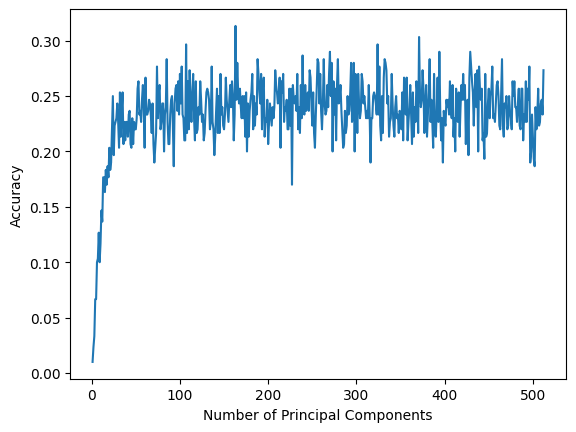

In [48]:

# Note: Data is already pre-processed in the previous step. 

acc_list = []

for comp in range(1, VIT_input.shape[1]+1):
    pca = PCA(comp)
    pca.fit(VIT_input)
    red_data = pca.transform(VIT_input)
    
    knn = KNeighborsClassifier()
    X_train, X_test, y_train, y_test = train_test_split(red_data, labels, test_size=0.2, random_state = None)
    
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=1, average='weighted')
    recall = recall_score(y_test, y_pred, zero_division=1, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print("For VIT Dataset: Accuracy={}, Precision={}, Recall={}, F1 Score={}".format(accuracy, precision, recall, f1))

    acc_list.append(accuracy)
    
x_plot = list(range(1, VIT_input.shape[1] + 1))
plt.plot(x_plot, acc_list)
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.plot()
plt.show()

We can observe that as the number of Principal Components increases, the accuracy gradually increases. <br>
We can get accuracies very close to the optimal value with very less components. <br>
From the figure we can observe that at approximately 50-70 Prinicipal Components will give around the same accuracy. <br>

## 1.2 Pictionary Dataset

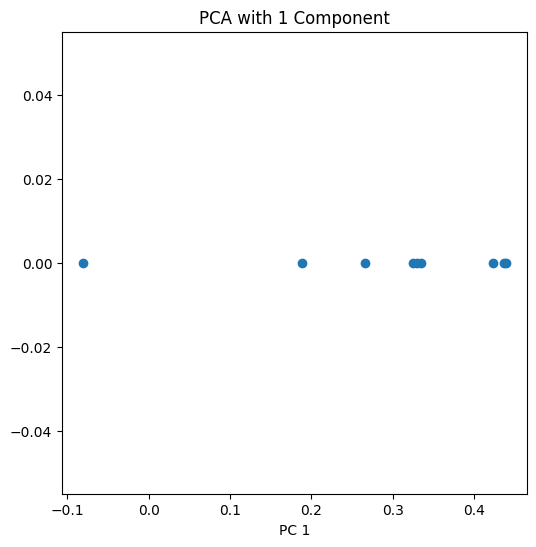

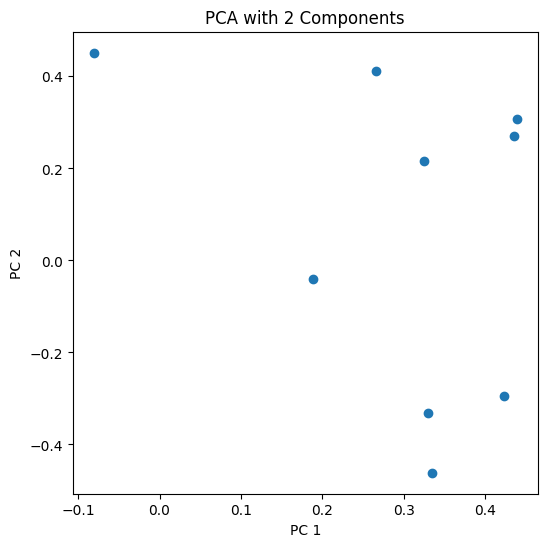

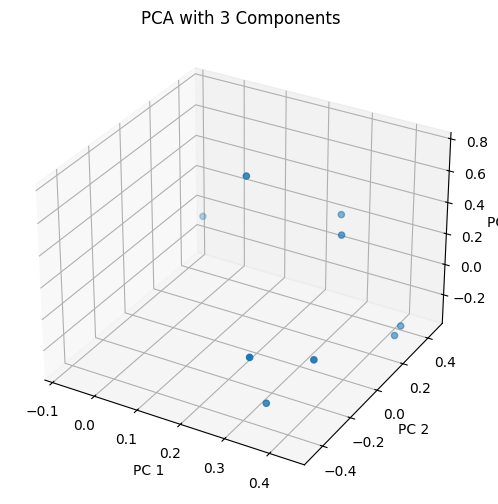

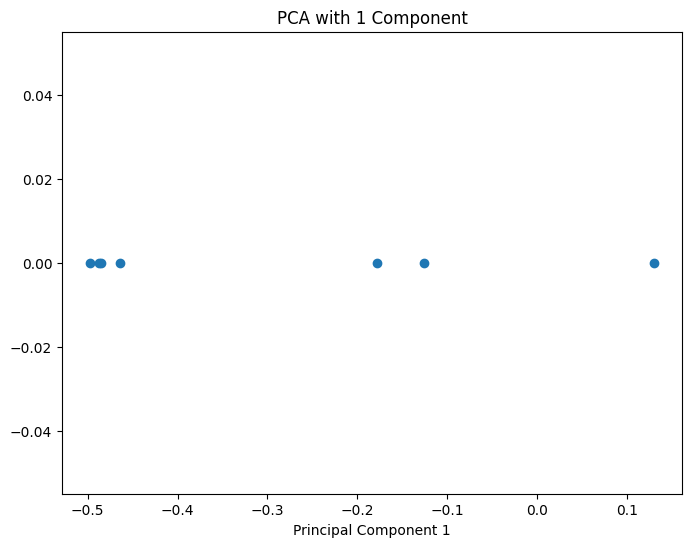

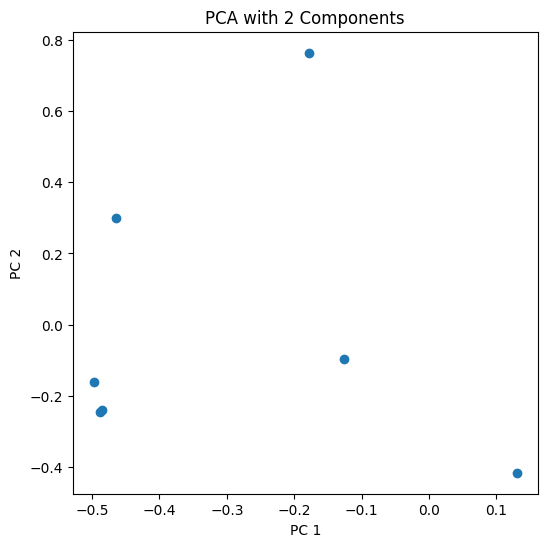

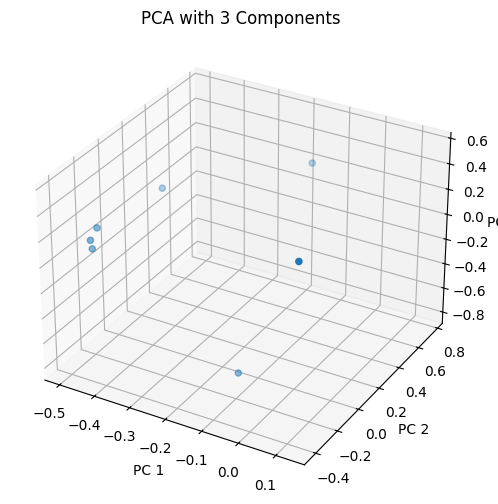

In [49]:
drawer_input = pd.read_csv('./smai_assignment_pictionary/drawer_attributes.csv')
guesser_input = pd.read_csv('./smai_assignment_pictionary/guesser_attributes.csv')

drawer_input = np.array([drawer_input])
guesser_input = np.array([guesser_input])

drawer_input = drawer_input.reshape(drawer_input.shape[1], drawer_input.shape[2])
guesser_input = guesser_input.reshape(guesser_input.shape[1], guesser_input.shape[2])     

# ============================================================ For Drawer Dataset =====================================================

pca = PCA(1)
drawer_input = pca.preprocess(drawer_input)
pca.fit(drawer_input)

plt.figure(figsize=(6, 6))
plt.scatter(pca.components, np.zeros(pca.components.shape)) 
plt.xlabel('PC 1')
plt.title('PCA with 1 Component')
plt.show()

pca = PCA(2)
drawer_input = pca.preprocess(drawer_input)
pca.fit(drawer_data)

plt.figure(figsize=(6, 6))
plt.scatter(pca.components[:, 0], pca.components[:, 1]) 
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA with 2 Components')
plt.show()

pca = PCA(3)
drawer_input = pca.preprocess(drawer_input)
pca.fit(drawer_data)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca.components[:, 0], pca.components[:, 1], pca.components[:, 2]) 
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('PCA with 3 Components')
plt.show()

# ==================================================== For Guesser Dataset ====================================================

pca = PCA(1)
guesser_input = pca.preprocess(guesser_input)
pca.fit(guesser_data)

plt.figure(figsize=(8, 6))
plt.scatter(pca.components, np.zeros(pca.components.shape)) 
plt.xlabel('Principal Component 1')
plt.title('PCA with 1 Component')
plt.show()

pca = PCA(2)
guesser_input = pca.preprocess(guesser_input)
pca.fit(guesser_data)

plt.figure(figsize=(6, 6))
plt.scatter(pca.components[:, 0], pca.components[:, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA with 2 Components')
plt.show()

pca = PCA(3)
guesser_input = pca.preprocess(guesser_input)
pca.fit(guesser_data)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca.components[:, 0], pca.components[:, 1], pca.components[:, 2])
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('PCA with 3 Components')
plt.show()


### What does each of the new axes that are obtained from PCA represent? <br>
Each new axes represent the new transformed axis which will be used as the new basis for the data. <br>
These are the new dimensions that the original data has been reduced to. 